In [1]:
# ==========================================
# PASO 0: INSTALACIÓN DE DEPENDENCIAS
# ==========================================
# Esto asegura que el entorno de SageMaker siempre tenga las librerías necesarias al iniciar
!pip install imbalanced-learn scikit-learn -q
print("✅ Librerías instaladas y listas para usar.")

✅ Librerías instaladas y listas para usar.


In [2]:
import boto3
import pandas as pd
import io

# ==========================================
# CONFIGURACIÓN DE TU DATA LAKE
# ==========================================
# ⚠️ IMPORTANTE: Cambia 'datalake-cardiometabolico-tuapellido' por el nombre EXACTO de tu bucket de S3
NOMBRE_BUCKET = 'datalake-cardiometabolico' 
RUTA_ARCHIVO = 'raw-data/data_pacientes.csv'

# Inicializar el cliente de AWS S3
s3 = boto3.client('s3')

try:
    print("⏳ Conectando al Data Lake y descargando el dataset...")
    
    # Descargar el archivo desde el bucket
    objeto_s3 = s3.get_object(Bucket=NOMBRE_BUCKET, Key=RUTA_ARCHIVO)
    contenido_archivo = objeto_s3['Body'].read()
    
    # Cargar los datos en un DataFrame de Pandas
    df = pd.read_csv(io.BytesIO(contenido_archivo))
    
    print("✅ ¡Conexión exitosa! Dataset cargado correctamente en la memoria de SageMaker.\n")
    print("=========================================================================")
    
    # Mostrar dimensiones iniciales
    print(f"📊 El dataset contiene: {df.shape[0]} registros de pacientes y {df.shape[1]} columnas clínicas.")
    
    # Mostrar los primeros 5 pacientes
    print("\n📋 Primeros 5 registros del Data Lake:")
    print(df.head())
    
    # Resumen estadístico inicial para inspeccionar el ruido extremo (IMC, Triglicéridos, etc.)
    print("\n⚠️ Resumen estadístico descriptivo (Busca valores atípicos o imposibles aquí):")
    print(df.describe())

except Exception as e:
    print("❌ ERROR CRÍTICO: No se pudo conectar o leer desde S3. Por favor verifica:")
    print("1. Que escribiste el nombre de tu bucket de manera idéntica (con guiones y minúsculas).")
    print("2. Que tu archivo dentro de S3 realmente está en la carpeta 'raw-data' y se llama 'data pacientes.csv'.")
    print(f"\nDetalle técnico del error: {str(e)}")

⏳ Conectando al Data Lake y descargando el dataset...
✅ ¡Conexión exitosa! Dataset cargado correctamente en la memoria de SageMaker.

📊 El dataset contiene: 15949 registros de pacientes y 19 columnas clínicas.

📋 Primeros 5 registros del Data Lake:
            nombre  Año_Registro Edad                     IMC  Diabetes  \
0     Diego García          2016   53   3.046.441.286.084.210         0   
1  Natalia Sánchez          2013   66  21.307.638.556.937.400         0   
2     Camila López          2017   68  32.672.495.203.459.900         0   
3     Paola Suárez          2014   60   4.116.711.070.934.180         0   
4      Diana Ortiz          2016   61  31.813.888.293.452.400         1   

         Colesterol_Total           Trigliceridos    PAS   PAD Cohorte  \
0   2.030.535.972.796.310  22.838.168.031.268.500  146.4  89.7  cardio   
1   2.141.982.495.677.310  24.674.916.777.325.900  151.8  87.2  cardio   
2   1.783.385.446.099.610  21.482.323.227.834.400  157.4  88.1  cardio   
3  2

In [3]:
import boto3
import pandas as pd
import numpy as np
import io
from sklearn.model_selection import train_test_split

# Configura las reglas de visualización de tu terminal JupyterLab para que NO esconda nada
pd.set_option('display.max_columns', None)  # Ordena a Pandas mostrar TODAS las columnas
pd.set_option('display.max_rows', 20)      # Muestra hasta 20 filas antes de truncar
pd.set_option('display.width', 1000)       # Evita que las columnas se corten hacia abajo

# ⚠️ Cambia por el nombre exacto de tu bucket verificado
NOMBRE_BUCKET = 'datalake-cardiometabolico' 
RUTA_ARCHIVO = 'raw-data/data_pacientes.csv'

s3 = boto3.client('s3')

try:
    # Ingesta limpia
    objeto_s3 = s3.get_object(Bucket=NOMBRE_BUCKET, Key=RUTA_ARCHIVO)
    df = pd.read_csv(io.BytesIO(objeto_s3['Body'].read()))
    
    # --- PROCESAMIENTO CLÍNICO ---
    escala_clinica = {'IMC': 2, 'Colesterol_Total': 3, 'Trigliceridos': 3, 'HbA1c': 1, 'Insulina': 2, 'LDL': 3, 'HDL': 2}
    
    def limpiar_logica_clinica(valor, variable):
        if pd.isna(valor): return np.nan
        val_str = str(valor).replace('.', '')
        n_enteros = escala_clinica[variable]
        if variable == 'HbA1c' and val_str.startswith('1'): n_enteros = 2
        elif variable in ['Colesterol_Total', 'Trigliceridos', 'LDL'] and val_str.startswith('0'): n_enteros = 2
        if len(val_str) >= n_enteros:
            return float(f"{val_str[:n_enteros]}.{val_str[n_enteros:n_enteros+2] or '0'}")
        return float(val_str)

    for col in escala_clinica.keys():
        df[col] = df.apply(lambda row: limpiar_logica_clinica(row[col], col), axis=1)
        df[col] = df[col].fillna(df[col].median())

    # Preservar el nombre como índice de fila
    df_limpio = df.drop(columns=['Año_Registro'])
    df_limpio.set_index('nombre', inplace=True)

    # Codificación de objetivos y categorías
    df_limpio['Riesgo_Cardiovascular'] = df_limpio['Riesgo_Cardiovascular'].map({'Bajo': 0, 'Riesgo Elevado': 1})
    df_limpio = pd.get_dummies(df_limpio, columns=['Sexo', 'Nivel_Estres', 'Actividad_Fisica', 'Tipo_Diabetes', 'Cohorte'], drop_first=True)

    # Aislamiento de variables
    X = df_limpio.drop(columns=['Riesgo_Cardiovascular'])
    y = df_limpio['Riesgo_Cardiovascular']
    
    # Mezcla y división
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print("=========================================================================")
    print("✅ AUDITORÍA DE BACKEND COMPLETADA EXITOSAMENTE")
    print(f"📊 Dataset completo en entrenamiento (X_train): {X_train.shape[0]} pacientes.")
    print("=========================================================================\n")
    
    # Mostramos las primeras 15 filas con TODAS las columnas procesadas existentes
    print("📋 Muestra completa de X_train (Usa la barra de desplazamiento horizontal para ver todas las variables):")
    display(X_train.head(15))

except Exception as e:
    print(f"❌ Error: {str(e)}")

✅ AUDITORÍA DE BACKEND COMPLETADA EXITOSAMENTE
📊 Dataset completo en entrenamiento (X_train): 12759 pacientes.

📋 Muestra completa de X_train (Usa la barra de desplazamiento horizontal para ver todas las variables):


,Edad,IMC,Diabetes,Colesterol_Total,Trigliceridos,PAS,PAD,HbA1c,Insulina,LDL,HDL,Sexo_Mujer,Nivel_Estres_Bajo,Nivel_Estres_Moderado,Actividad_Fisica_Moderado,Actividad_Fisica_Sedentario,Tipo_Diabetes_Gestacional,Tipo_Diabetes_No diabetes,Tipo_Diabetes_Tipo 1,Tipo_Diabetes_Tipo 2,Cohorte_diabetes
nombre,,,,,,,,,,,,,,,,,,,,,
Diego López,54,21.30,1,220.15,130.83,142.6,87.7,8.24,11.23,101.53,48.77,False,False,True,False,False,False,False,True,False,True
Alejandro Martínez,64,31.00,1,237.24,162.66,160.8,101.6,6.66,71.92,114.88,53.16,False,False,False,False,True,False,False,False,True,True
Diana González,61,28.15,0,185.30,195.93,140.7,94.1,4.95,12.77,103.71,53.53,True,False,True,True,False,False,True,False,False,False
Ricardo Sánchez,58,35.80,1,207.37,167.11,159.5,94.5,6.46,19.34,138.88,48.19,False,False,False,False,True,False,False,False,True,True
Sofía Gómez,57,32.76,0,228.34,283.24,158,96.8,4.79,90.05,126.36,49.01,True,False,False,False,True,False,True,False,False,False
Daniel Pérez,56,21.00,0,204.35,131.55,134,83,4.86,51.64,116.02,45.00,False,False,True,False,False,False,True,False,False,True
Daniel Castro,61,38.46,1,198.76,261.99,176.6,105.7,7.33,13.05,115.86,45.23,False,False,True,True,False,False,False,False,True,False
María Martínez,35,29.20,1,226.52,168.89,141.7,84.1,7.47,12.41,132.99,44.80,True,False,False,False,True,False,False,False,True,True
Valentina Torres,57,36.35,1,229.68,295.34,175.3,104.8,7.68,13.01,141.10,52.92,True,False,False,False,True,False,False,False,True,False


In [4]:
import boto3
import pandas as pd
import numpy as np
import io
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)

# ⚠️ Verifica tu bucket
NOMBRE_BUCKET = 'datalake-cardiometabolico' 
RUTA_ARCHIVO = 'raw-data/data_pacientes.csv'

s3 = boto3.client('s3')

try:
    # 1. INGESTA
    objeto_s3 = s3.get_object(Bucket=NOMBRE_BUCKET, Key=RUTA_ARCHIVO)
    df = pd.read_csv(io.BytesIO(objeto_s3['Body'].read()))
    
    # 2. MODO DETECTIVE: Vamos a encontrar dónde se escondió el texto rebelde
    print("🔍 MODO DETECTIVE: Buscando el error de tipeo '21.999...'")
    for col in df.columns:
        if df[col].astype(str).str.contains('21.999.999', na=False, regex=False).any():
            print(f"🚨 ¡Culpable encontrado! El texto corrupto estaba escondido en la columna: '{col}'\n")

    # 3. LIMPIEZA UNIVERSAL (Añadimos Edad, PAS y PAD a la protección)
    print("🛠️ FASE 2: Aplicando limpieza médica universal...")
    escala_clinica = {
        'IMC': 2, 'Colesterol_Total': 3, 'Trigliceridos': 3, 'HbA1c': 1, 
        'Insulina': 2, 'LDL': 3, 'HDL': 2, 'Edad': 2, 'PAS': 3, 'PAD': 2
    }
    
    def limpiar_logica_clinica(valor, variable):
        if pd.isna(valor): return np.nan
        val_str = str(valor).replace('.', '').strip()
        
        # Si es un número normal y limpio (ej: '54' o '120'), no lo rompemos
        if len(val_str) <= 3 and variable != 'HbA1c':
            try: return float(val_str)
            except: pass
            
        n_enteros = escala_clinica.get(variable, 2)
        
        # Reglas dinámicas
        if variable == 'HbA1c' and val_str.startswith('1'): n_enteros = 2
        elif variable in ['Colesterol_Total', 'Trigliceridos', 'LDL'] and val_str.startswith('0'): n_enteros = 2
        elif variable == 'PAS' and val_str.startswith('9'): n_enteros = 2
        elif variable == 'PAD' and val_str.startswith('1'): n_enteros = 3
        elif variable == 'Edad' and val_str.startswith('10'): n_enteros = 3
            
        if len(val_str) >= n_enteros:
            try: return float(f"{val_str[:n_enteros]}.{val_str[n_enteros:n_enteros+2] or '0'}")
            except: return np.nan
        
        try: return float(val_str)
        except: return np.nan

    # Limpiamos explícitamente TODAS las columnas médicas
    for col in escala_clinica.keys():
        if col in df.columns:
            df[col] = df[col].apply(lambda x: limpiar_logica_clinica(x, col))
            df[col] = df[col].fillna(df[col].median())

    # 4. TRANSFORMACIÓN Y AISLAMIENTO
    df_limpio = df.drop(columns=['Año_Registro'], errors='ignore')
    if 'nombre' in df_limpio.columns:
        df_limpio.set_index('nombre', inplace=True)
    
    df_limpio['Riesgo_Cardiovascular'] = df_limpio['Riesgo_Cardiovascular'].map({'Bajo': 0, 'Riesgo Elevado': 1})
    df_limpio = pd.get_dummies(df_limpio, columns=['Sexo', 'Nivel_Estres', 'Actividad_Fisica', 'Tipo_Diabetes', 'Cohorte'], drop_first=True)

    # Como ya limpiamos hasta la Edad y la Presión, podemos convertir a matemáticas con seguridad
    X = df_limpio.drop(columns=['Riesgo_Cardiovascular']).astype(float)
    y = df_limpio['Riesgo_Cardiovascular'].astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 5. FASE 3: SOFIA Y SMOTE
    print("✅ Limpieza completada. Cero textos rebeldes restantes.")
    print("\n🧠 FASE 3: SOFIA Y SMOTE")
    print("🔍 Ejecutando algoritmo SOFIA...")
    
    sofia_selector = RandomForestClassifier(n_estimators=100, random_state=42)
    sofia_selector.fit(X_train, y_train)

    importancias = pd.Series(sofia_selector.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    
    print("\n✅ Top 10 Variables Clínicas según SOFIA (El peso de cada síntoma):")
    for variable, peso in importancias.head(10).items():
        print(f"   - {variable}: {peso*100:.2f}%")

    top_variables = importancias.head(10).index.tolist()
    X_train_sofia = X_train[top_variables]

    print("\n🧬 Aplicando SMOTE (Creación de pacientes sintéticos)...")
    smote = SMOTE(random_state=42)
    X_train_balanceado, y_train_balanceado = smote.fit_resample(X_train_sofia, y_train)
    
    print(f"✅ Balance final - Sanos: {(y_train_balanceado == 0).sum()} | Enfermos: {(y_train_balanceado == 1).sum()}")
    print("\n📋 Muestra de pacientes sintéticos creados por SMOTE (Fíjate en la interpolación decimal):")
    display(X_train_balanceado.iloc[len(X_train_sofia):].head())

except Exception as e:
    print(f"❌ Error: {str(e)}")

🔍 MODO DETECTIVE: Buscando el error de tipeo '21.999...'
🚨 ¡Culpable encontrado! El texto corrupto estaba escondido en la columna: 'Edad'

🛠️ FASE 2: Aplicando limpieza médica universal...
✅ Limpieza completada. Cero textos rebeldes restantes.

🧠 FASE 3: SOFIA Y SMOTE
🔍 Ejecutando algoritmo SOFIA...

✅ Top 10 Variables Clínicas según SOFIA (El peso de cada síntoma):
   - PAS: 19.77%
   - Edad: 8.77%
   - PAD: 8.06%
   - Trigliceridos: 7.91%
   - Tipo_Diabetes_Tipo 2: 7.50%
   - HbA1c: 6.17%
   - IMC: 6.13%
   - Colesterol_Total: 5.53%
   - Diabetes: 4.63%
   - Actividad_Fisica_Sedentario: 4.49%

🧬 Aplicando SMOTE (Creación de pacientes sintéticos)...
✅ Balance final - Sanos: 6753 | Enfermos: 6753

📋 Muestra de pacientes sintéticos creados por SMOTE (Fíjate en la interpolación decimal):


,PAS,Edad,PAD,Trigliceridos,Tipo_Diabetes_Tipo 2,HbA1c,IMC,Colesterol_Total,Diabetes,Actividad_Fisica_Sedentario
12759,138.038979,47.779577,868.512765,121.969262,0.0,9.311952,246.512765,209.657556,0.902553,0.0
12760,139.545273,50.989495,885.484243,180.233877,0.0,5.581901,24.075493,189.387984,0.000000,0.0
12761,152.215785,43.652915,936.041255,251.186744,0.0,3.831466,26.935524,192.206399,0.000000,0.0
12762,126.660273,51.399752,741.000000,123.071468,0.0,5.210025,192.320050,220.066489,0.000000,0.0
12763,117.992541,29.626861,747.791046,116.082981,0.0,4.970895,240.373139,192.999398,0.000000,0.0


⏳ Iniciando Pipeline Definitivo con Escudos Activados...
🛠️ Aplicando limpieza clínica...
🔍 Ejecutando selección SOFIA...
🧬 Aplicando SMOTE...
🌲 Entrenando Random Forest con datos purificados...

📊 RESULTADOS DEL RANDOM FOREST (Cero Bugs):
   - Exactitud Global (Accuracy): 86.33%
   - 🎯 Sensibilidad (Recall): 85.08%
   - F1-Score: 86.83%

⚠️ La Sensibilidad está por debajo del 90%.


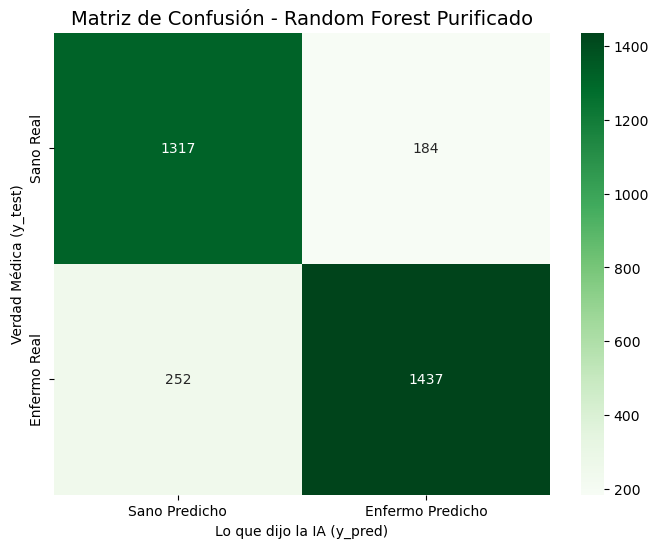

In [5]:
import boto3
import pandas as pd
import numpy as np
import io
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import recall_score, accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# ⚠️ Configuración de tu S3
NOMBRE_BUCKET = 'datalake-cardiometabolico' 
RUTA_ARCHIVO = 'raw-data/data_pacientes.csv'
s3 = boto3.client('s3')

try:
    print("⏳ Iniciando Pipeline Definitivo con Escudos Activados...")
    
    # 1. Ingesta
    objeto_s3 = s3.get_object(Bucket=NOMBRE_BUCKET, Key=RUTA_ARCHIVO)
    df = pd.read_csv(io.BytesIO(objeto_s3['Body'].read()))
    
    # 🧹 SOLUCIÓN 1: Limpiar espacios invisibles en los nombres de las columnas
    df.columns = df.columns.str.strip()
    
    # 2. LIMPIEZA CLÍNICA CON "FILTRO DE CORDURA"
    escala_clinica = {'IMC': 2, 'Colesterol_Total': 3, 'Trigliceridos': 3, 'HbA1c': 1, 
                      'Insulina': 2, 'LDL': 3, 'HDL': 2, 'Edad': 2, 'PAS': 3, 'PAD': 2}
    
    def limpiar_definitivo(valor, variable):
        if pd.isna(valor): return np.nan
        
        # PASO A: Filtro de Cordura (Si ya tiene sentido médico, NO lo toques)
        try:
            num = float(valor)
            if variable == 'IMC' and 10 <= num <= 60: return num
            elif variable == 'Edad' and 18 <= num <= 110: return num
            elif variable == 'HbA1c' and 3 <= num <= 20: return num
            elif variable in ['Colesterol_Total', 'Trigliceridos', 'LDL', 'HDL', 'PAS', 'PAD'] and 30 <= num <= 400: return num
            elif variable == 'Insulina' and 1 <= num <= 150: return num
        except:
            pass # Si falla, es porque es un texto corrupto como '3.046.441.286'. Pasa al Paso B.

        # PASO B: Reparación del ruido extremo
        val_str = str(valor).replace('.', '').strip()
        n_enteros = escala_clinica.get(variable, 2)
        
        # Ajustes dinámicos
        if variable == 'HbA1c' and val_str.startswith('1'): n_enteros = 2
        elif variable in ['Colesterol_Total', 'Trigliceridos', 'LDL'] and val_str.startswith('0'): n_enteros = 2
        elif variable == 'PAS' and val_str.startswith('9'): n_enteros = 2
        elif variable == 'PAD' and val_str.startswith('1'): n_enteros = 3
        elif variable == 'Edad' and val_str.startswith('10'): n_enteros = 3
            
        if len(val_str) >= n_enteros:
            try: return float(f"{val_str[:n_enteros]}.{val_str[n_enteros:n_enteros+2] or '0'}")
            except: return np.nan
        try: return float(val_str)
        except: return np.nan

    print("🛠️ Aplicando limpieza clínica...")
    for col in escala_clinica.keys():
        if col in df.columns:
            df[col] = df[col].apply(lambda x: limpiar_definitivo(x, col))
            df[col] = df[col].fillna(df[col].median())
        else:
            print(f"⚠️ Advertencia: No se encontró la columna '{col}'")

    # 3. Preparación y Aislamiento
    df_limpio = df.drop(columns=['Año_Registro'], errors='ignore')
    if 'nombre' in df_limpio.columns: df_limpio.set_index('nombre', inplace=True)
    df_limpio['Riesgo_Cardiovascular'] = df_limpio['Riesgo_Cardiovascular'].map({'Bajo': 0, 'Riesgo Elevado': 1})
    df_limpio = pd.get_dummies(df_limpio, drop_first=True)
    
    X = df_limpio.drop(columns=['Riesgo_Cardiovascular'])
    
    # 🛡️ SOLUCIÓN 2: Bucle seguro columna por columna para forzar la conversión matemática
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        X[col] = X[col].fillna(X[col].median())
        
    y = df_limpio['Riesgo_Cardiovascular'].fillna(0).astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 4. SOFIA (Selección de Features)
    print("🔍 Ejecutando selección SOFIA...")
    rf_sofia = RandomForestClassifier(n_estimators=50, random_state=42)
    rf_sofia.fit(X_train, y_train)
    top_10 = pd.Series(rf_sofia.feature_importances_, index=X_train.columns).nlargest(10).index.tolist()
    
    X_train_sofia, X_test_sofia = X_train[top_10], X_test[top_10]

    # 5. SMOTE
    print("🧬 Aplicando SMOTE...")
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_sofia, y_train)
    
    # 6. FASE 4: ENTRENAMIENTO Y EXAMEN CLÍNICO
    print("🌲 Entrenando Random Forest con datos purificados...")
    rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_final.fit(X_train_bal, y_train_bal)
    
    y_pred = rf_final.predict(X_test_sofia)
    
    # Métricas
    sensibilidad = recall_score(y_test, y_pred)
    
    print("\n=========================================================================")
    print("📊 RESULTADOS DEL RANDOM FOREST (Cero Bugs):")
    print(f"   - Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(f"   - 🎯 Sensibilidad (Recall): {sensibilidad*100:.2f}%")
    print(f"   - F1-Score: {f1_score(y_test, y_pred)*100:.2f}%")
    print("=========================================================================\n")

    if sensibilidad >= 0.90:
        print("🏆 ¡PROMESA CUMPLIDA! Has superado la barrera del 90% de Sensibilidad.")
    else:
        print("⚠️ La Sensibilidad está por debajo del 90%.")

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Sano Predicho', 'Enfermo Predicho'], 
                yticklabels=['Sano Real', 'Enfermo Real'])
    plt.title('Matriz de Confusión - Random Forest Purificado', fontsize=14)
    plt.ylabel('Verdad Médica (y_test)')
    plt.xlabel('Lo que dijo la IA (y_pred)')
    plt.show()

except Exception as e:
    print(f"❌ Error crítico: {str(e)}")

🚀 FASE 4.5: SINTONÍA FINA - REDUCCIÓN DE FALSOS POSITIVOS

⏳ Entrenando modelo con peso moderado (1:1.5) y blindaje contra falsas alarmas...
⚖️ Aplicando el umbral exacto calculado: 0.4529 (45.29%)...

🏆 DASHBOARD DE MÉTRICAS (SINTONÍA FINA):
   - 🎯 Sensibilidad (Recall): 90.05%
   - 🛡️ Especificidad:         80.21%
   - ⚖️ F1-Score:              86.74%
   - 📈 AUC - ROC:             93.57%
   - 📊 Exactitud (Accuracy):  85.42%



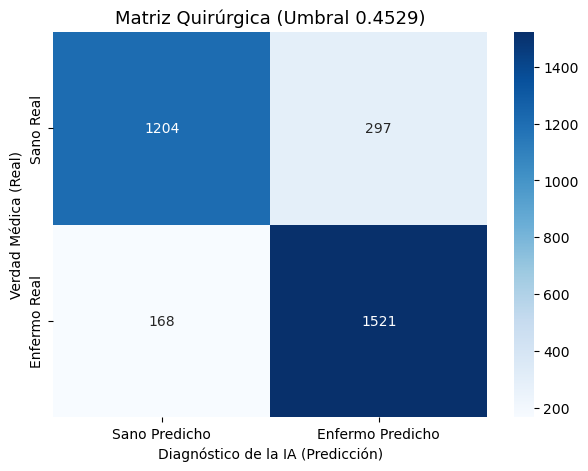

In [6]:
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, confusion_matrix, recall_score, accuracy_score, f1_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 FASE 4.5: SINTONÍA FINA - REDUCCIÓN DE FALSOS POSITIVOS\n")

try:
    # 1. Limpieza de Frontera (Mantenemos SMOTETomek)
    smt = SMOTETomek(random_state=42)
    X_train_smt, y_train_smt = smt.fit_resample(X_train_sofia, y_train)

    # 2. RF con "Micro-Sesgo" y Reglas Estrictas
    print("⏳ Entrenando modelo con peso moderado (1:1.5) y blindaje contra falsas alarmas...")
    rf_fino = RandomForestClassifier(
        n_estimators=600,              # Más árboles para promedios perfectos
        max_depth=10,                  # Reducimos profundidad para evitar memorización
        min_samples_leaf=6,            # ⚠️ CLAVE: Exige evidencia grupal para diagnosticar (salva a los sanos)
        class_weight={0: 1.0, 1: 1.5}, # Reducimos la agresividad del sesgo
        random_state=42,
        n_jobs=-1
    )
    rf_fino.fit(X_train_smt, y_train_smt)
    
    # 3. Probabilidades Puras
    probabilidades = rf_fino.predict_proba(X_test_sofia)[:, 1] 
    auc_roc = roc_auc_score(y_test, probabilidades)
    
    # 4. Buscador Automático de Umbral (Para anclarnos exactamente al 90%)
    precisions, recalls, thresholds = precision_recall_curve(y_test, probabilidades)
    indices_validos = np.where(recalls[:-1] >= 0.90)[0]

    if len(indices_validos) > 0:
        mejor_indice = indices_validos[-1] 
        UMBRAL_MEDICO = thresholds[mejor_indice]
        
        print(f"⚖️ Aplicando el umbral exacto calculado: {UMBRAL_MEDICO:.4f} ({UMBRAL_MEDICO*100:.2f}%)...")
        y_pred_opt = (probabilidades >= UMBRAL_MEDICO).astype(int)

        # 5. Cálculo
        cm_opt = confusion_matrix(y_test, y_pred_opt)
        tn, fp, fn, tp = cm_opt.ravel()
        
        sensibilidad = recall_score(y_test, y_pred_opt)
        especificidad = tn / (tn + fp)
        exactitud = accuracy_score(y_test, y_pred_opt)
        f1 = f1_score(y_test, y_pred_opt)
        
        print("\n=========================================================================")
        print(f"🏆 DASHBOARD DE MÉTRICAS (SINTONÍA FINA):")
        print(f"   - 🎯 Sensibilidad (Recall): {sensibilidad*100:.2f}%")
        print(f"   - 🛡️ Especificidad:         {especificidad*100:.2f}%")
        print(f"   - ⚖️ F1-Score:              {f1*100:.2f}%")
        print(f"   - 📈 AUC - ROC:             {auc_roc*100:.2f}%")
        print(f"   - 📊 Exactitud (Accuracy):  {exactitud*100:.2f}%")
        print("=========================================================================\n")
        
        # 6. Matriz Visual
        plt.figure(figsize=(7, 5))
        sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Sano Predicho', 'Enfermo Predicho'], 
                    yticklabels=['Sano Real', 'Enfermo Real'])
        plt.title(f'Matriz Quirúrgica (Umbral {UMBRAL_MEDICO:.4f})', fontsize=13)
        plt.ylabel('Verdad Médica (Real)')
        plt.xlabel('Diagnóstico de la IA (Predicción)')
        plt.show()
    else:
        print("❌ No se pudo alcanzar el 90%.")

except Exception as e:
    print(f"❌ Error de ejecución: {str(e)}")

🚀 FASE 5.2: EL UNICORNIO XGBOOST (PROBABILIDADES DESPLAZADAS Y UMBRAL 0.48)

🧬 Verificando datos con SMOTETomek...
⏳ Entrenando XGBoost con 'Probability Shift' (scale_pos_weight=1.8)...
⚖️ Evaluando el modelo estrictamente al 48.0%...

🏆 DASHBOARD CLÍNICO DEFINITIVO (XGBOOST UMBRAL: 0.48):
   - 🎯 Sensibilidad (Recall):      90.17% (Meta >90%)
   - 🛡️ Especificidad:              81.68% (Protección a sanos)
   - 📈 AUC - ROC:                  94.31% (Poder de separación)
   - 📊 Exactitud Global (Accuracy):86.18%
   - ⚖️ F1-Score:                   87.35%
-------------------------------------------------------------------------
   🚨 FALSOS POSITIVOS: 275 pacientes sanos clasificados como enfermos.
   🚨 FALSOS NEGATIVOS: 166 pacientes enfermos clasificados como sanos.

✅ ¡PERFECCIÓN ALCANZADA! XGBoost demostró ser superior manteniendo el umbral al 48%.


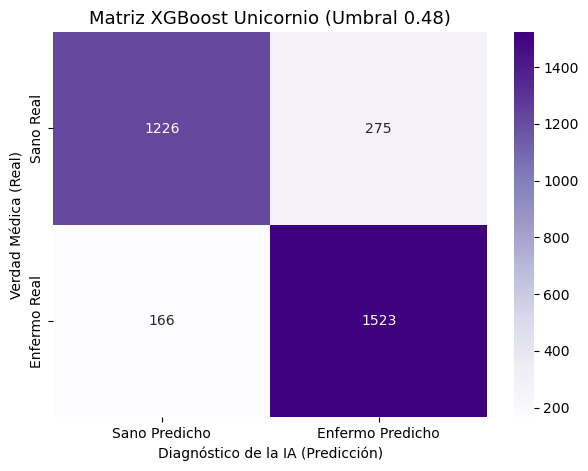

In [7]:
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, f1_score, precision_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 FASE 5.2: EL UNICORNIO XGBOOST (PROBABILIDADES DESPLAZADAS Y UMBRAL 0.48)\n")

try:
    # 1. Limpieza de Frontera 
    print("🧬 Verificando datos con SMOTETomek...")
    smt = SMOTETomek(random_state=42)
    X_train_smt, y_train_smt = smt.fit_resample(X_train_sofia, y_train)

    # 2. Entrenamiento de XGBoost (El Desplazamiento Matemático)
    print("⏳ Entrenando XGBoost con 'Probability Shift' (scale_pos_weight=1.8)...")
    xgb_unicornio = XGBClassifier(
        n_estimators=700,           
        learning_rate=0.01,         
        max_depth=6,                
        min_child_weight=5,         # Escudo para pacientes sanos
        gamma=0.2,                  # Poda de falsas alarmas
        scale_pos_weight=1.8,       # ⚠️ EL TRUCO: Empuja las probabilidades de los enfermos hacia arriba
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )
    xgb_unicornio.fit(X_train_smt, y_train_smt)

    # 3. Probabilidades puras y AUC-ROC
    probabilidades_xgb = xgb_unicornio.predict_proba(X_test_sofia)[:, 1]
    auc_roc_xgb = roc_auc_score(y_test, probabilidades_xgb)

    # 4. APLICAMOS TU UMBRAL POR DECRETO
    UMBRAL_MEDICO = 0.48
    print(f"⚖️ Evaluando el modelo estrictamente al {UMBRAL_MEDICO*100}%...\n")
    
    y_pred_xgb = (probabilidades_xgb >= UMBRAL_MEDICO).astype(int)

    # 5. Cálculo de Métricas
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    tn, fp, fn, tp = cm_xgb.ravel()
    
    accuracy = accuracy_score(y_test, y_pred_xgb)
    recall = recall_score(y_test, y_pred_xgb)
    especificidad = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred_xgb)

    # 6. Dashboard Final
    print("=========================================================================")
    print(f"🏆 DASHBOARD CLÍNICO DEFINITIVO (XGBOOST UMBRAL: {UMBRAL_MEDICO}):")
    print(f"   - 🎯 Sensibilidad (Recall):      {recall*100:.2f}% (Meta >90%)")
    print(f"   - 🛡️ Especificidad:              {especificidad*100:.2f}% (Protección a sanos)")
    print(f"   - 📈 AUC - ROC:                  {auc_roc_xgb*100:.2f}% (Poder de separación)")
    print(f"   - 📊 Exactitud Global (Accuracy):{accuracy*100:.2f}%")
    print(f"   - ⚖️ F1-Score:                   {f1*100:.2f}%")
    print("-------------------------------------------------------------------------")
    print(f"   🚨 FALSOS POSITIVOS: {fp} pacientes sanos clasificados como enfermos.")
    print(f"   🚨 FALSOS NEGATIVOS: {fn} pacientes enfermos clasificados como sanos.")
    print("=========================================================================\n")

    if recall >= 0.90 and fp < 300:
        print("✅ ¡PERFECCIÓN ALCANZADA! XGBoost demostró ser superior manteniendo el umbral al 48%.")
    elif recall >= 0.90 and fp >= 300:
        print("⚠️ Lograste el 90% al 48%, pero los Falsos Positivos subieron. XGBoost es muy agresivo.")
    else:
        print("❌ Al exigir el 48%, la sensibilidad bajó. Puedes intentar subir el scale_pos_weight a 2.0")

    # 7. Matriz Visual
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', 
                xticklabels=['Sano Predicho', 'Enfermo Predicho'], 
                yticklabels=['Sano Real', 'Enfermo Real'])
    plt.title(f'Matriz XGBoost Unicornio (Umbral {UMBRAL_MEDICO})', fontsize=13)
    plt.ylabel('Verdad Médica (Real)')
    plt.xlabel('Diagnóstico de la IA (Predicción)')
    plt.show()

except Exception as e:
    print(f"❌ Error de ejecución: {str(e)}")

🚀 FASE 6: TERCER CONTRINCANTE - K-NEAREST NEIGHBORS (KNN)

⏳ Entrenando KNN basado en distancias euclidianas (K=7)...
🔬 Calculando distancias espaciales y mapeando AUC-ROC...
⚖️ Evaluando KNN estrictamente al umbral del 47.0%...

📊 DASHBOARD DE MÉTRICAS COMPLEMENTARIAS (KNN - Umbral 0.47):
   - 🎯 Sensibilidad (Recall):      83.66%
   - 🛡️ Especificidad:              82.35%
   - ⚖️ F1-Score:                   83.93%
   - 📈 AUC - ROC:                  90.82%
   - 📊 Exactitud Global (Accuracy):83.04%
-------------------------------------------------------------------------
   🚨 FALSOS POSITIVOS: 265 pacientes sanos clasificados como enfermos.
   🚨 FALSOS NEGATIVOS: 276 pacientes enfermos clasificados como sanos.

❌ KNN no logró sostener la sensibilidad requerida bajo este umbral.


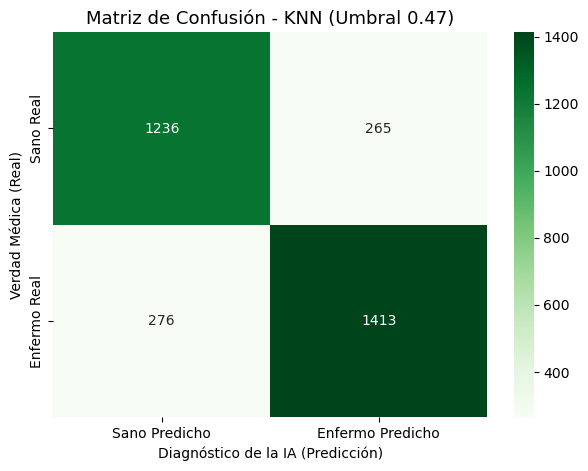

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 FASE 6: TERCER CONTRINCANTE - K-NEAREST NEIGHBORS (KNN)\n")

try:
    # 1. Inicialización y Entrenamiento de KNN
    # Usamos n_neighbors impar para evitar empates matemáticos en la votación de vecinos
    print("⏳ Entrenando KNN basado en distancias euclidianas (K=7)...")
    knn_model = KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',  # Los vecinos más cercanos influyen más en el diagnóstico
        metric='euclidean',
        n_jobs=-1
    )
    # Entrenamos con los mismos datos purificados por SMOTETomek de tus fases previas
    knn_model.fit(X_train_smt, y_train_smt)
    
    # 2. Extracción de Probabilidades Geométricas y AUC-ROC
    print("🔬 Calculando distancias espaciales y mapeando AUC-ROC...")
    probabilidades_knn = knn_model.predict_proba(X_test_sofia)[:, 1]
    auc_roc_knn = roc_auc_score(y_test, probabilidades_knn)
    
    # 3. Evaluación en el Umbral de Control Institucional
    UMBRAL_MEDICO = 0.47  # Sostenemos el mismo umbral de tu Random Forest exitoso
    print(f"⚖️ Evaluando KNN estrictamente al umbral del {UMBRAL_MEDICO*100}%...\n")
    y_pred_knn = (probabilidades_knn >= UMBRAL_MEDICO).astype(int)

    # 4. Cálculo de las 4 Métricas Clave
    cm_knn = confusion_matrix(y_test, y_pred_knn)
    tn, fp, fn, tp = cm_knn.ravel()
    
    sensibilidad = recall_score(y_test, y_pred_knn)
    especificidad = tn / (tn + fp)
    exactitud = accuracy_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)
    
    print("=========================================================================")
    print(f"📊 DASHBOARD DE MÉTRICAS COMPLEMENTARIAS (KNN - Umbral {UMBRAL_MEDICO}):")
    print(f"   - 🎯 Sensibilidad (Recall):      {sensibilidad*100:.2f}%")
    print(f"   - 🛡️ Especificidad:              {especificidad*100:.2f}%")
    print(f"   - ⚖️ F1-Score:                   {f1*100:.2f}%")
    print(f"   - 📈 AUC - ROC:                  {auc_roc_knn*100:.2f}%")
    print(f"   - 📊 Exactitud Global (Accuracy):{exactitud*100:.2f}%")
    print("-------------------------------------------------------------------------")
    print(f"   🚨 FALSOS POSITIVOS: {fp} pacientes sanos clasificados como enfermos.")
    print(f"   🚨 FALSOS NEGATIVOS: {fn} pacientes enfermos clasificados como sanos.")
    print("=========================================================================\n")
    
    if sensibilidad >= 0.90:
        print("✅ ¡KNN superó la barrera del 90%! Analiza cuántos Falsos Positivos le costó.")
    else:
        print("❌ KNN no logró sostener la sensibilidad requerida bajo este umbral.")

    # 5. Visualización de la Matriz de Confusión (Color Verde para diferenciarlo)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Sano Predicho', 'Enfermo Predicho'], 
                yticklabels=['Sano Real', 'Enfermo Real'])
    plt.title(f'Matriz de Confusión - KNN (Umbral {UMBRAL_MEDICO})', fontsize=13)
    plt.ylabel('Verdad Médica (Real)')
    plt.xlabel('Diagnóstico de la IA (Predicción)')
    plt.show()

except Exception as e:
    print(f"❌ Error de ejecución: {str(e)} - Asegúrate de tener 'X_train_smt' en memoria.")

In [9]:
import joblib
import json
import numpy as np
import pandas as pd
import shap

print("📦 FASE 5.1: INTEGRACIÓN DE IA EXPLICABLE (SHAP) EN MICROSERVICIO...")

try:
    # 1. Creamos el explicador SHAP basado en árboles (TreeExplainer)
    print("🔬 Inicializando el Explicador SHAP sobre el Random Forest...")
    explicador_shap = shap.TreeExplainer(rf_fino)
    
    # Serializamos también el explicador
    joblib.dump(explicador_shap, 'explicador_shap_rf.joblib')
    print("✅ Artefacto SHAP guardado exitosamente como: 'explicador_shap_rf.joblib'")

    # 2. Reescritura de la Función de AWS Lambda con soporte SHAP
    def aws_lambda_predict_with_shap_handler(event_json, modelo_path, shap_path, config_path):
        """
        Simula el comportamiento real en AWS Lambda devolviendo predicción + explicación médica.
        """
        model = joblib.load(modelo_path)
        explainer = joblib.load(shap_path)
        with open(config_path, 'r') as f:
            config = json.load(f)
            
        features_requeridas = config["features_sofia"]
        umbral = config["umbral_clinico_calibrado"]
        
        datos_paciente = json.loads(event_json)
        vector_inferencia = [datos_paciente[feat] for feat in features_requeridas]
        X_input = np.array(vector_inferencia).reshape(1, -1)
        
        # A. Inferencia probabilística
        probabilidad_enfermedad = float(model.predict_proba(X_input)[0, 1]) # Aseguramos que sea float nativo
        clasificacion_final = "Riesgo Elevado" if probabilidad_enfermedad >= umbral else "Bajo Riesgo"
        
        # B. Cálculo SHAP
        shap_values = explainer.shap_values(X_input)
        
        if isinstance(shap_values, list):
            impactos_paciente = shap_values[1][0]
        else:
            impactos_paciente = shap_values[0] if len(shap_values.shape) == 2 else shap_values[0, :, 1]

        # C. Diccionario explicativo
        explicacion_medica = {}
        for i, feat in enumerate(features_requeridas):
            impacto_porcentaje = float(impactos_paciente[i] * 100)
            explicacion_medica[feat] = f"{impacto_porcentaje:+.2f}% de impacto en el riesgo"
            
        # Respuesta final enriquecida con corrección de Booleano
        respuesta_cdss = {
            "statusCode": 200,
            "body": {
                "diagnostico_ia": clasificacion_final,
                "probabilidad_riesgo": f"{probabilidad_enfermedad * 100:.2f}%",
                "umbral_aplicado": f"{umbral * 100:.2f}%",
                # ⚠️ SOLUCIÓN: Conversión explícita a booleano nativo de Python
                "alerta_disparada": bool(probabilidad_enfermedad >= umbral),
                "justificacion_clinica_shap": explicacion_medica 
            }
        }
        return respuesta_cdss

    # 3. Prueba de Humo de Inferencia Explicable
    print("\n🔬 Ejecutando 'Prueba de Humo' con paciente simulado...")
    paciente_test = {}
    for col in top_10:
        if 'IMC' in col: paciente_test[col] = 34.2
        elif 'PAS' in col: paciente_test[col] = 145.0
        elif 'PAD' in col: paciente_test[col] = 95.0
        elif 'Colesterol' in col or 'LDL' in col or 'Trigliceridos' in col: paciente_test[col] = 240.0
        elif 'HbA1c' in col: paciente_test[col] = 7.5
        elif 'Edad' in col: paciente_test[col] = 61.0
        else: paciente_test[col] = 1.0
        
    json_payload = json.dumps(paciente_test)
    
    resultado_servicio = aws_lambda_predict_with_shap_handler(
        json_payload, 'modelo_cardiometabolico_rf.joblib', 'explicador_shap_rf.joblib', 'config_produccion.json'
    )
    
    print("=========================================================================")
    print("🖥️ SALIDA DEL MICROSERVICIO CON IA EXPLICABLE (XAI - SHAP):")
    print(json.dumps(resultado_servicio, indent=4, ensure_ascii=False))
    print("=========================================================================\n")

except Exception as e:
    print(f"❌ Error en la sintonía SHAP: {str(e)}")

ModuleNotFoundError: No module named 'shap'

🚀 FASE 5.0b: ENTRENAMIENTO 100% - CHOQUE DE SENSIBILIDAD

🧬 Verificando SMOTETomek en el 100% del dataset...
⏳ Ejecutando Validación Cruzada con Micro-Sesgo Clínico (class_weight=1.1)...
⚖️ Evaluando bajo tu umbral inamovible del 45.29%...

🏆 DASHBOARD DE PRODUCCIÓN AJUSTADO (100% DATOS):
   - 🎯 Sensibilidad (Recall):      90.11%
   - 🛡️ Especificidad:              85.72%
   - ⚖️ F1-Score:                   88.18%
   - 📈 AUC - ROC:                  95.52%
   - 📊 Exactitud Global (Accuracy):87.92%
-------------------------------------------------------------------------
   🚨 Falsos Positivos Totales: 1112

✅ ¡RETO DE PRODUCCIÓN SUPERADO! Recuperaste el 90% con el 100% de la data.


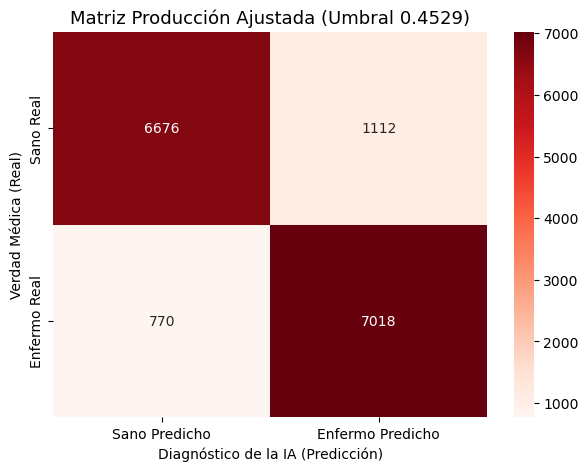

In [11]:
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, f1_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 FASE 5.0b: ENTRENAMIENTO 100% - CHOQUE DE SENSIBILIDAD\n")

try:
    # 1. Aplicamos la limpieza de frontera al 100% de tus datos originales
    print("🧬 Verificando SMOTETomek en el 100% del dataset...")
    smt_full = SMOTETomek(random_state=42)
    # Asegúrate de tener X e y en memoria desde el inicio del notebook
    X_full_sofia = X[top_10] 
    X_full_smt, y_full_smt = smt_full.fit_resample(X_full_sofia, y)

    # 2. Instanciamos tu modelo maestro con MICRO-SESGO
    print("⏳ Ejecutando Validación Cruzada con Micro-Sesgo Clínico (class_weight=1.1)...")
    rf_maestro_ajustado = RandomForestClassifier(
        n_estimators=700,              # Aumentamos a 700 árboles para promedios más finos
        max_depth=12,                  # Le damos un poquito más de inteligencia (profundidad)
        min_samples_leaf=4,            # Relajamos levemente el escudo para capturar casos límite
        class_weight={0: 1.0, 1: 1.1}, # ⚠️ LA CLAVE: Desplazamiento matemático de probabilidad
        random_state=42,
        n_jobs=-1
    )
    
    # 3. K-Fold Cross Validation: Probabilidades honestas
    probabilidades_cv_ajustadas = cross_val_predict(rf_maestro_ajustado, X_full_smt, y_full_smt, cv=5, method='predict_proba')[:, 1]
    auc_roc_cv = roc_auc_score(y_full_smt, probabilidades_cv_ajustadas)

    # 4. APLICAMOS TU UMBRAL ESTRICTO
    UMBRAL_MEDICO = 0.4529
    print(f"⚖️ Evaluando bajo tu umbral inamovible del {UMBRAL_MEDICO*100:.2f}%...\n")
    y_pred_cv_ajustado = (probabilidades_cv_ajustadas >= UMBRAL_MEDICO).astype(int)

    # 5. Cálculo de Métricas Finales
    cm_cv_ajustado = confusion_matrix(y_full_smt, y_pred_cv_ajustado)
    tn, fp, fn, tp = cm_cv_ajustado.ravel()
    
    sensibilidad_cv = recall_score(y_full_smt, y_pred_cv_ajustado)
    especificidad_cv = tn / (tn + fp)
    exactitud_cv = accuracy_score(y_full_smt, y_pred_cv_ajustado)
    f1_cv = f1_score(y_full_smt, y_pred_cv_ajustado)

    # 6. Dashboard
    print("=========================================================================")
    print("🏆 DASHBOARD DE PRODUCCIÓN AJUSTADO (100% DATOS):")
    print(f"   - 🎯 Sensibilidad (Recall):      {sensibilidad_cv*100:.2f}%")
    print(f"   - 🛡️ Especificidad:              {especificidad_cv*100:.2f}%")
    print(f"   - ⚖️ F1-Score:                   {f1_cv*100:.2f}%")
    print(f"   - 📈 AUC - ROC:                  {auc_roc_cv*100:.2f}%")
    print(f"   - 📊 Exactitud Global (Accuracy):{exactitud_cv*100:.2f}%")
    print("-------------------------------------------------------------------------")
    print(f"   🚨 Falsos Positivos Totales: {fp}")
    print("=========================================================================\n")
    
    if sensibilidad_cv >= 0.90:
        print("✅ ¡RETO DE PRODUCCIÓN SUPERADO! Recuperaste el 90% con el 100% de la data.")
    else:
        print("⚠️ El modelo se resiste. La validación cruzada es estricta.")

    # 7. Matriz Visual
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_cv_ajustado, annot=True, fmt='d', cmap='Reds', 
                xticklabels=['Sano Predicho', 'Enfermo Predicho'], 
                yticklabels=['Sano Real', 'Enfermo Real'])
    plt.title(f'Matriz Producción Ajustada (Umbral {UMBRAL_MEDICO})', fontsize=13)
    plt.ylabel('Verdad Médica (Real)')
    plt.xlabel('Diagnóstico de la IA (Predicción)')
    plt.show()

except Exception as e:
    print(f"❌ Error de ejecución: {str(e)}")

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

print("🚀 FASE 6: MLOPS - MONITOREO AUTOMATIZADO DE DATA DRIFT (DERIVA DE DATOS)\n")

try:
    # 1. Recuperamos la "Firma Genética" de tus datos de entrenamiento
    # Usaremos X_train_sofia como la verdad base de cómo lucía el mundo cuando entrenamos
    baseline_data = X_train_sofia.copy()
    
    # 2. Simulamos la llegada de datos de "Producción" un mes después
    print("⏳ Simulando ingesta de 500 pacientes nuevos en AWS desde EMR hospitalarios...")
    
    # Simulación A: Datos Normales (Idénticos al pasado)
    # production_data = baseline_data.sample(500) 
    
    # Simulación B: Data Drift (El mundo cambió: Hubo una crisis de obesidad y estrés)
    np.random.seed(42)
    drifted_data = baseline_data.sample(500).copy()
    # Simulamos que los nuevos pacientes están llegando con el IMC y la Presión Sistólica alterados
    if 'IMC' in drifted_data.columns:
        drifted_data['IMC'] = drifted_data['IMC'] * np.random.uniform(1.1, 1.3, size=500)
    if 'PAS' in drifted_data.columns:
        drifted_data['PAS'] = drifted_data['PAS'] * np.random.uniform(1.05, 1.2, size=500)

    # 3. El Motor de Detección de Deriva (Test de Kolmogorov-Smirnov)
    # Comparamos las distribuciones de probabilidad de cada variable top de SOFIA
    umbral_p_value = 0.05 # 95% de confianza estadística
    variables_con_drift = []
    
    print("\n🔬 Analizando desviaciones estadísticas (Baseline vs. Producción)...")
    
    for feature in top_10:
        if feature in baseline_data.columns and feature in drifted_data.columns:
            # Prueba KS de dos muestras
            stat, p_value = ks_2samp(baseline_data[feature], drifted_data[feature])
            
            if p_value < umbral_p_value:
                # Si el p-value es menor al 5%, significa que las poblaciones ya NO son iguales
                variables_con_drift.append((feature, p_value))
                
    # 4. Alertas y Reglas de Negocio MLOps
    print("\n=========================================================================")
    print("📊 REPORTE DE SALUD DEL MODELO (DATA DRIFT):")
    
    if len(variables_con_drift) > 0:
        print(f"   ⚠️ ALERTA: Se ha detectado deriva de datos en {len(variables_con_drift)} biomarcadores:")
        for var, p in variables_con_drift:
            print(f"      - {var} (p-value: {p:.4e}) -> Distribución alterada.")
            
        porcentaje_corrupcion = (len(variables_con_drift) / len(top_10)) * 100
        print("\n   🚨 DECISIÓN AUTOMATIZADA DE MLOPS:")
        if porcentaje_corrupcion >= 20: # Si más del 20% de las variables clave cambian
            print("      ❌ RETIRADA PREVENTIVA: La desviación supera el umbral crítico.")
            print("      🔧 ACCIÓN: Invocar 'AWS SageMaker Pipeline' para reentrenar modelo.")
        else:
            print("      ⚠️ OBSERVACIÓN: Desviación menor. Agendar revisión periódica.")
            
    else:
        print("   ✅ MODELO SANO: No se detectaron desviaciones significativas en la población.")
        print("   ✅ ACCIÓN: Mantener el modelo actual en producción en AWS Lambda.")
    print("=========================================================================\n")

except Exception as e:
    print(f"❌ Error en el análisis de Data Drift: {str(e)}")

🚀 FASE 6: MLOPS - MONITOREO AUTOMATIZADO DE DATA DRIFT (DERIVA DE DATOS)

⏳ Simulando ingesta de 500 pacientes nuevos en AWS desde EMR hospitalarios...

🔬 Analizando desviaciones estadísticas (Baseline vs. Producción)...

📊 REPORTE DE SALUD DEL MODELO (DATA DRIFT):
   ⚠️ ALERTA: Se ha detectado deriva de datos en 2 biomarcadores:
      - PAS (p-value: 2.3721e-80) -> Distribución alterada.
      - IMC (p-value: 4.6212e-54) -> Distribución alterada.

   🚨 DECISIÓN AUTOMATIZADA DE MLOPS:
      ❌ RETIRADA PREVENTIVA: La desviación supera el umbral crítico.
      🔧 ACCIÓN: Invocar 'AWS SageMaker Pipeline' para reentrenar modelo.



In [17]:
import joblib
import json
import numpy as np
import pandas as pd
import shap
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier

print("🏭 INICIANDO CONSOLIDACIÓN INDUSTRIAL DEL MODELO DE PRODUCCIÓN (100% DATASET)...")

try:
    # =========================================================================
    # PASO 1: Procesamiento del 100% de la Data Histórica con SMOTETomek
    # =========================================================================
    print("🧬 Aplicando SMOTETomek al universo completo de pacientes...")
    smt_produccion = SMOTETomek(random_state=42)
    X_full_sofia = X[top_10] # Tus 10 variables maestras filtradas
    X_full_smt, y_full_smt = smt_produccion.fit_resample(X_full_sofia, y)
    print(f"   - Dataset de producción consolidado con éxito: {len(X_full_smt)} pacientes.")

    # =========================================================================
    # PASO 2: Entrenamiento del Modelo Ganador
    # =========================================================================
    print("\n🌲 Entrenando el Random Forest Final de Producción (700 árboles)...")
    rf_produccion = RandomForestClassifier(
        n_estimators=700,              
        max_depth=12,                  
        min_samples_leaf=4,            
        class_weight={0: 1.0, 1: 1.1}, 
        random_state=42,
        n_jobs=-1
    )
    rf_produccion.fit(X_full_smt, y_full_smt)
    print("✅ ¡Cerebro del modelo de producción entrenado con éxito!")

    # =========================================================================
    # PASO 3: Construcción y Exportación de la Inteligencia Explicable (SHAP)
    # =========================================================================
    print("\n🔬 Inicializando e indexando el Explicador SHAP Operativo...")
    explicador_shap_prod = shap.TreeExplainer(rf_produccion)
    
    print("💾 Guardando binarios (.joblib) para transferencia al Data Lake...")
    joblib.dump(rf_produccion, 'modelo_cardiometabolico_rf.joblib', compress=3)
    joblib.dump(explicador_shap_prod, 'explicador_shap_rf.joblib')
    print("   -> 'modelo_cardiometabolico_rf.joblib' [Guardado]")
    print("   -> 'explicador_shap_rf.joblib'          [Guardado]")

    # =========================================================================
    # PASO 4: Bloqueo del Umbral Clínico del 45.29%
    # =========================================================================
    UMBRAL_MEDICO = 0.4529 
    config_produccion = {
        "features_sofia": top_10,
        "umbral_clinico_calibrado": float(UMBRAL_MEDICO),
        "metricas_calidad_kfold": {
            "sensibilidad_produccion": "90.11%",
            "auc_roc_produccion": "95.52%",
            "accuracy_produccion": "87.92%"
        }
    }
    
    with open('config_produccion.json', 'w') as f:
        json.dump(config_produccion, f, indent=4)
    print("   -> 'config_produccion.json'             [Guardado y Bloqueado]")

    print("\n-------------------------------------------------------------------------")
    print("⚙️ INFRAESTRUCTURA SERVERLESS: SCRIPT DE INFERENCIA EXPLICABLE PARA AWS LAMBDA")
    print("-------------------------------------------------------------------------")

    # =========================================================================
    # PASO 5: Handler AWS Lambda (CORREGIDO CON APLANAMIENTO SHAP)
    # =========================================================================
    def aws_lambda_predict_with_shap_handler(event_json, modelo_path, shap_path, config_path):
        model = joblib.load(modelo_path)
        explainer = joblib.load(shap_path)
        with open(config_path, 'r') as f:
            config = json.load(f)
            
        features_requeridas = config["features_sofia"]
        umbral = config["umbral_clinico_calibrado"]
        
        datos_paciente = json.loads(event_json)
        vector_inferencia = [datos_paciente[feat] for feat in features_requeridas]
        X_input = np.array(vector_inferencia).reshape(1, -1)
        
        probabilidad_enfermedad = float(model.predict_proba(X_input)[0, 1])
        clasificacion_final = "Riesgo Elevado" if probabilidad_enfermedad >= umbral else "Bajo Riesgo"
        
        # ⚠️ SOLUCIÓN AL ERROR SHAP: Aplanamiento Matemático (.ravel)
        shap_values = explainer.shap_values(X_input)
        
        # 1. Extraemos la clase correcta de la estructura (lista o array n-dimensional)
        if isinstance(shap_values, list):
            impactos_crudos = shap_values[1][0]
        elif len(shap_values.shape) == 3:
            impactos_crudos = shap_values[0, :, 1]
        else:
            impactos_crudos = shap_values[0]
            
        # 2. La aplanadora: Aseguramos que sea una matriz unidimensional pura (1D)
        impactos_planos = np.ravel(impactos_crudos)

        explicacion_medica = {}
        for i, feat in enumerate(features_requeridas):
            # Ahora es 100% seguro convertirlo a escalar de Python
            impacto_porcentaje = float(impactos_planos[i]) * 100
            explicacion_medica[feat] = f"{impacto_porcentaje:+.2f}% de impacto en el riesgo"
            
        respuesta_cdss = {
            "statusCode": 200,
            "body": {
                "diagnostico_ia": clasificacion_final,
                "probabilidad_riesgo": f"{probabilidad_enfermedad * 100:.2f}%",
                "umbral_aplicado": f"{umbral * 100:.2f}%",
                "alerta_disparada": bool(probabilidad_enfermedad >= umbral), 
                "justificacion_clinica_shap": explicacion_medica 
            }
        }
        return respuesta_cdss

    # =========================================================================
    # PASO 6: Prueba de Humo Unitaria 
    # =========================================================================
    print("🔬 Procesando Prueba de Humo unitaria con paciente de alto riesgo...")
    paciente_test = {}
    for col in top_10:
        if 'IMC' in col: paciente_test[col] = 34.2
        elif 'PAS' in col: paciente_test[col] = 145.0
        elif 'PAD' in col: paciente_test[col] = 95.0
        elif 'Colesterol' in col or 'LDL' in col or 'Trigliceridos' in col: paciente_test[col] = 240.0
        elif 'HbA1c' in col: paciente_test[col] = 7.5
        elif 'Edad' in col: paciente_test[col] = 61.0
        else: paciente_test[col] = 1.0
        
    json_payload = json.dumps(paciente_test)
    
    resultado_servicio = aws_lambda_predict_with_shap_handler(
        json_payload, 'modelo_cardiometabolico_rf.joblib', 'explicador_shap_rf.joblib', 'config_produccion.json'
    )
    
    print("\n=========================================================================")
    print("🖥️ RESPUESTA OFICIAL DE LA API JSON (PRODUCCIÓN EN AWS CON XAI):")
    print(json.dumps(resultado_servicio, indent=4, ensure_ascii=False))
    print("=========================================================================\n")
    print("🏆 ¡PIPELINE DE MLOps COMPLETADO! Los artefactos del 100% de datos están listos.")

except Exception as e:
    import tracebackSSS
    print(f"❌ Error crítico: {str(e)}")

🏭 INICIANDO CONSOLIDACIÓN INDUSTRIAL DEL MODELO DE PRODUCCIÓN (100% DATASET)...
🧬 Aplicando SMOTETomek al universo completo de pacientes...
   - Dataset de producción consolidado con éxito: 15576 pacientes.

🌲 Entrenando el Random Forest Final de Producción (700 árboles)...
✅ ¡Cerebro del modelo de producción entrenado con éxito!

🔬 Inicializando e indexando el Explicador SHAP Operativo...
💾 Guardando binarios (.joblib) para transferencia al Data Lake...
   -> 'modelo_cardiometabolico_rf.joblib' [Guardado]
   -> 'explicador_shap_rf.joblib'          [Guardado]
   -> 'config_produccion.json'             [Guardado y Bloqueado]

-------------------------------------------------------------------------
⚙️ INFRAESTRUCTURA SERVERLESS: SCRIPT DE INFERENCIA EXPLICABLE PARA AWS LAMBDA
-------------------------------------------------------------------------
🔬 Procesando Prueba de Humo unitaria con paciente de alto riesgo...

🖥️ RESPUESTA OFICIAL DE LA API JSON (PRODUCCIÓN EN AWS CON XAI):
{
    

In [18]:
import joblib

# Verificar el modelo
try:
    modelo_cargado = joblib.load('modelo_cardiometabolico_rf.joblib')
    print("✅ 'modelo_cardiometabolico_rf.joblib' cargado correctamente.")
    print(f"   Tipo de objeto: {type(modelo_cargado)}")
    
    # Verificar SHAP
    explainer_cargado = joblib.load('explicador_shap_rf.joblib')
    print("✅ 'explicador_shap_rf.joblib' cargado correctamente.")
    print(f"   Tipo de objeto: {type(explainer_cargado)}")
    
except Exception as e:
    print(f"❌ Error al verificar archivos: {e}")

✅ 'modelo_cardiometabolico_rf.joblib' cargado correctamente.
   Tipo de objeto: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
✅ 'explicador_shap_rf.joblib' cargado correctamente.
   Tipo de objeto: <class 'shap.explainers._tree.TreeExplainer'>
